# Clasp Queens surrogate: fixed-depth analytics

This notebook compares SMAC random-forest depths 5, 10, 15, 20, and 30 over SMAC seeds 0, 1, and 2. Lower PAR10 is better. Every incumbent and every proposal used for an error diagnostic is independently re-evaluated on **all training instances**, so curves are comparable even though SMAC selected incumbents from partial instance/seed evidence during optimization.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / 'results').is_dir():
    HERE = (Path.cwd() / 'experiments/aclib/clasp_queens_surrogate/01_initial_cq').resolve()
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from surrogate_analytics import (
    DEPTHS,
    N_TRIALS,
    SMAC_SEEDS,
    build_analysis_bundle,
    plot_final_incumbents,
    plot_incumbent_confidence_intervals,
    plot_incumbents_by_seed,
    plot_selected_seed_diagnostics,
    write_analysis_tables,
)

BENCHMARK_KEY = 'clasp_queens'
SELECTED_SMAC_SEED = 0
VALIDATION_QUANTILE_SEED = 0
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False})
print('Experiment:', HERE)

Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq


## Validation definition and data loading

For a trajectory checkpoint, the notebook takes the configuration ID that SMAC's intensifier considered incumbent at that trial. It then evaluates that configuration on every training instance and reports the arithmetic mean PAR10. The ACLib stochastic surrogate uses quantile seed 0, its deterministic median, for this independent validation. This fixed validation seed is not the SMAC seed; using one fixed value makes configurations from different runs directly comparable.

The first execution caches these full-training evaluations under `analytics_cache/`; later executions reuse the cache. The cell also exports the reconstructed trajectories and proposal diagnostics as CSV files.

In [2]:
bundle = build_analysis_bundle(
    HERE,
    BENCHMARK_KEY,
    selected_seed=SELECTED_SMAC_SEED,
    validation_quantile_seed=VALIDATION_QUANTILE_SEED,
)
table_files = write_analysis_tables(bundle)
availability = (
    bundle.final_incumbents.assign(complete=True)
    .pivot(index='depth', columns='smac_seed', values='complete')
)
display(availability)
print(
    f'Loaded {len(bundle.final_incumbents)} completed runs; '
    f'{bundle.training_instance_count} training instances; '
    f'{len(bundle.proposal_diagnostics)} trained proposals for seed '
    f'{SELECTED_SMAC_SEED}.'
)
print('Validation cache:', bundle.validation_cache_file)
print('Exported tables:')
for path in table_files:
    print(' ', path)

Validation cache hit: 6278 configurations from /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq/analytics_cache/full_training_validation_qseed_0.json.


smac_seed,0,1,2
depth,,,
5,True,True,True
10,True,True,True
15,True,True,True
20,True,True,True
30,True,True,True


Loaded 15 completed runs; 484 training instances; 7105 trained proposals for seed 0.
Validation cache: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq/analytics_cache/full_training_validation_qseed_0.json
Exported tables:
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq/analytics_cache/incumbent_trajectory_events.csv
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq/analytics_cache/final_incumbents.csv
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq/analytics_cache/selected_seed_proposal_diagnostics.csv
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/01_initial_cq/analytics_cache/selected_seed_ei_batch_variance.csv


## 1. Incumbent trajectory for each SMAC seed

Each figure fixes one SMAC seed and compares all five RF depths. A step changes exactly when SMAC's recorded incumbent changes; its height is that incumbent configuration's independently calculated mean PAR10 over all training instances. The final step is extended to trial 5,000. The first three figures use a linear performance axis; the following three repeat the same data with a logarithmic performance axis so relative improvements remain visible across different PAR10 magnitudes.

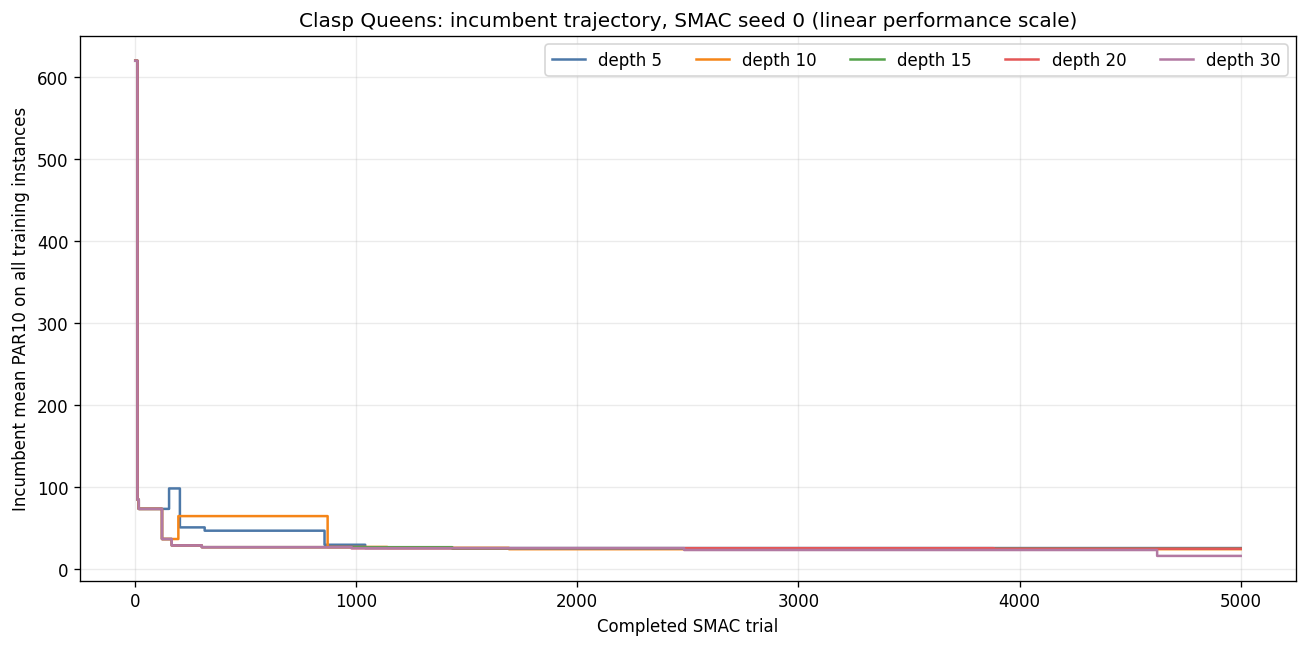

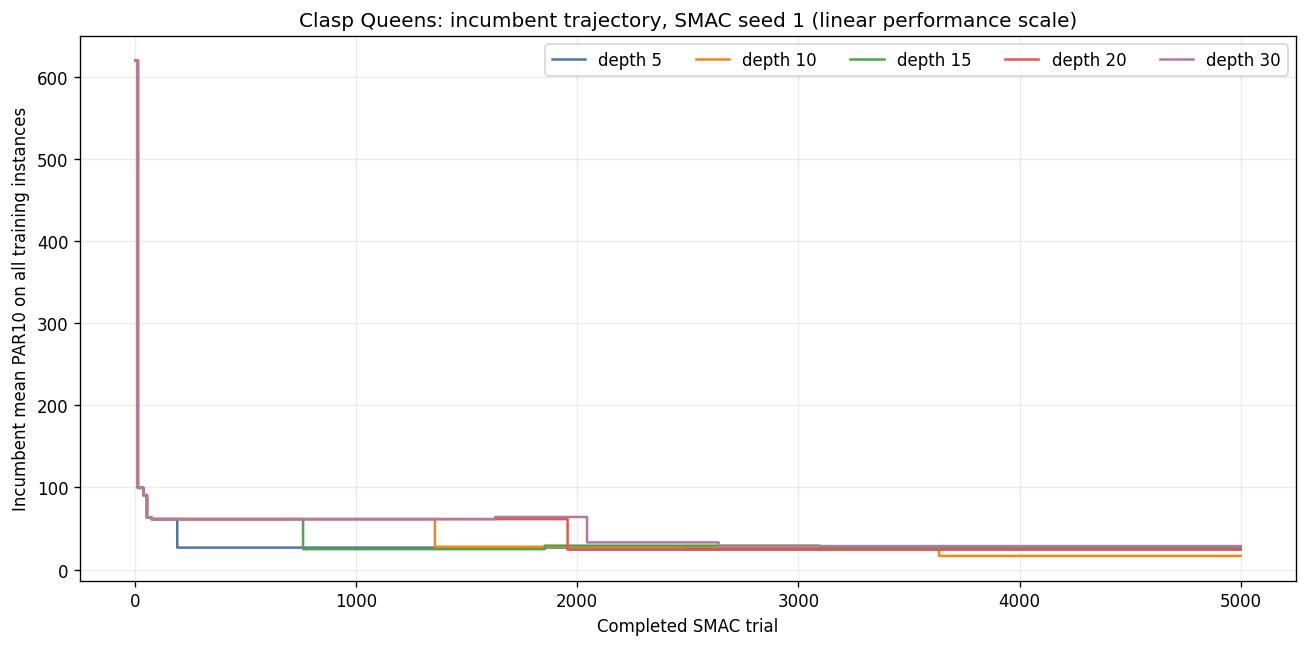

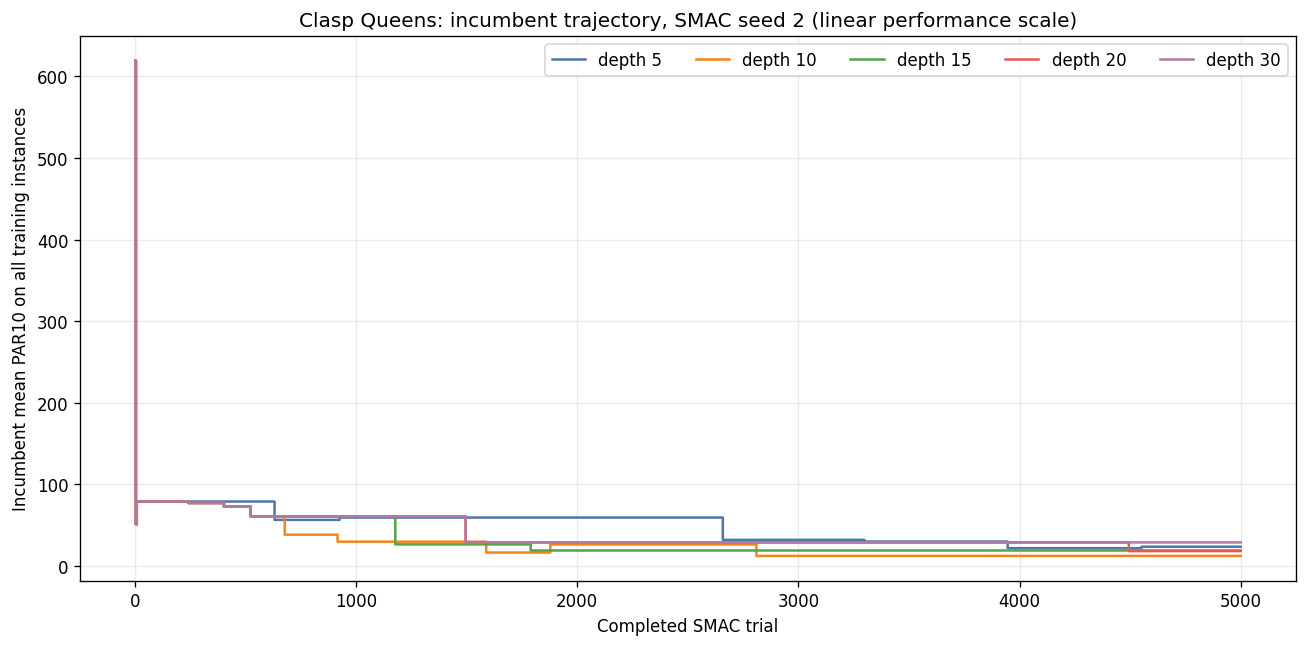

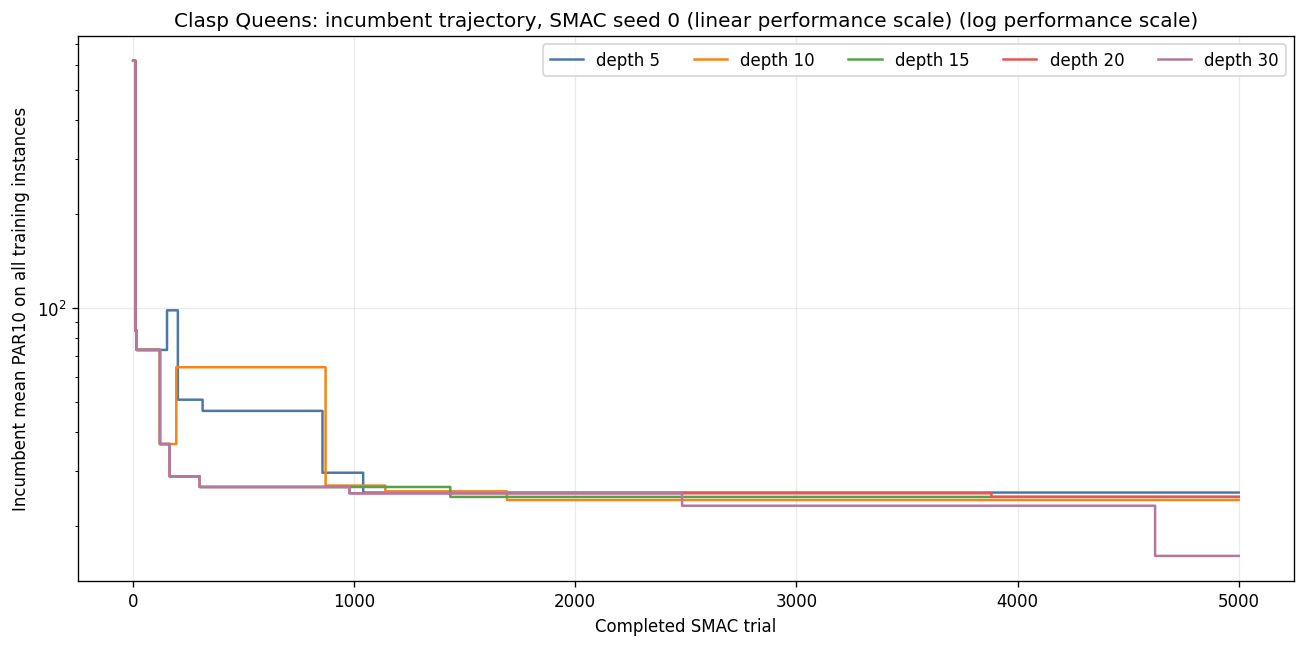

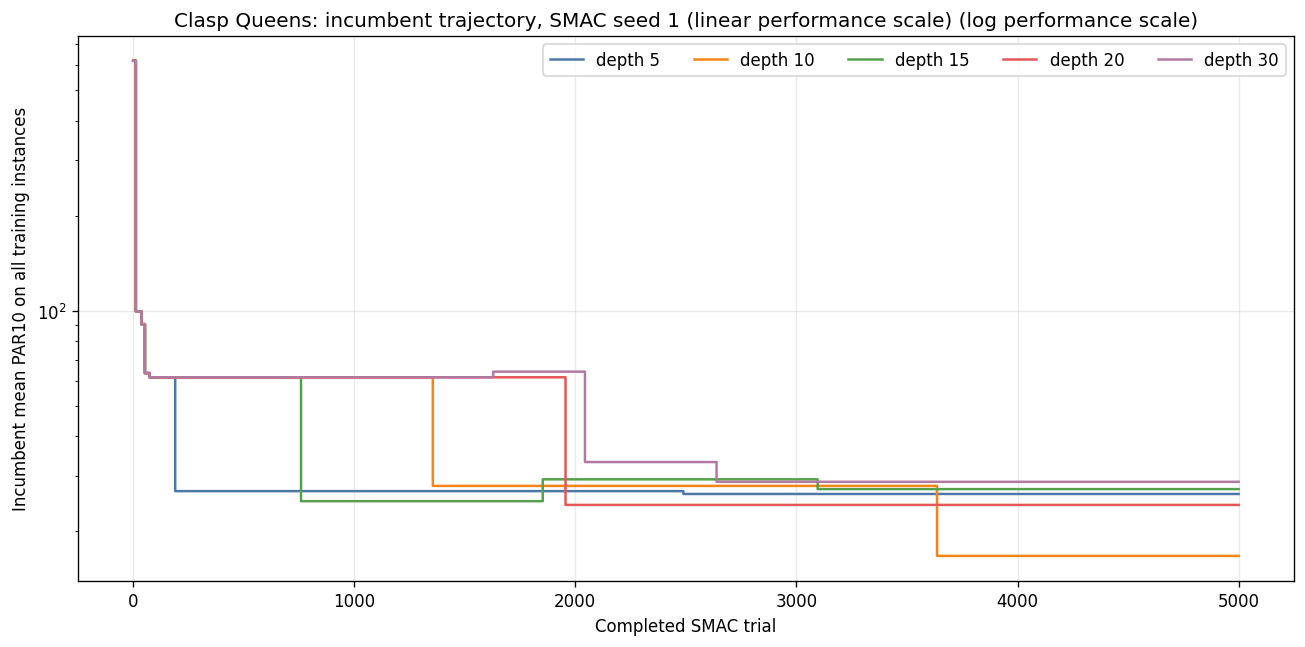

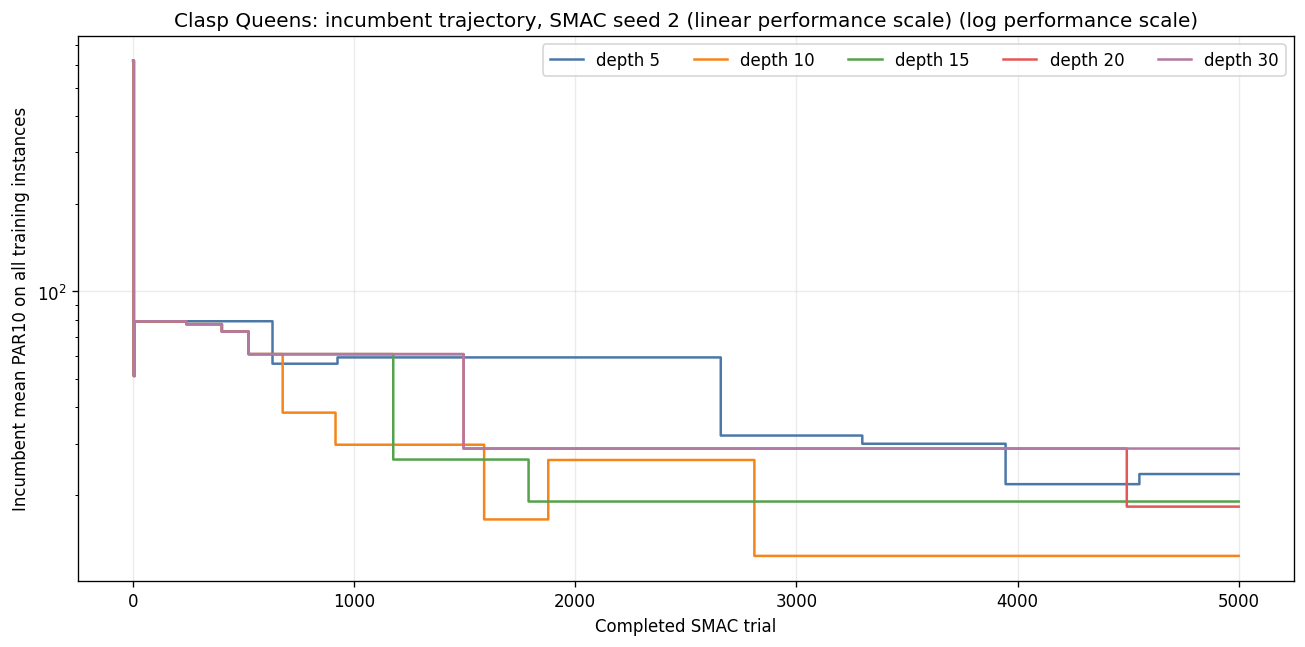

In [3]:
seed_figures = plot_incumbents_by_seed(bundle)
plt.show()

log_seed_figures = plot_incumbents_by_seed(bundle)
for figure in log_seed_figures:
    axis = figure.axes[0]
    axis.set_yscale('log')
    axis.set_title(axis.get_title() + ' (log performance scale)')
plt.show()

## 2. Incumbent trajectory averaged over SMAC seeds

For each depth, the line is the pointwise arithmetic mean of the three independently validated incumbent trajectories. The shaded band is a two-sided 95% Student-*t* confidence interval across the three SMAC seeds. With only three seeds, these intervals are estimates with two degrees of freedom and should be interpreted cautiously.

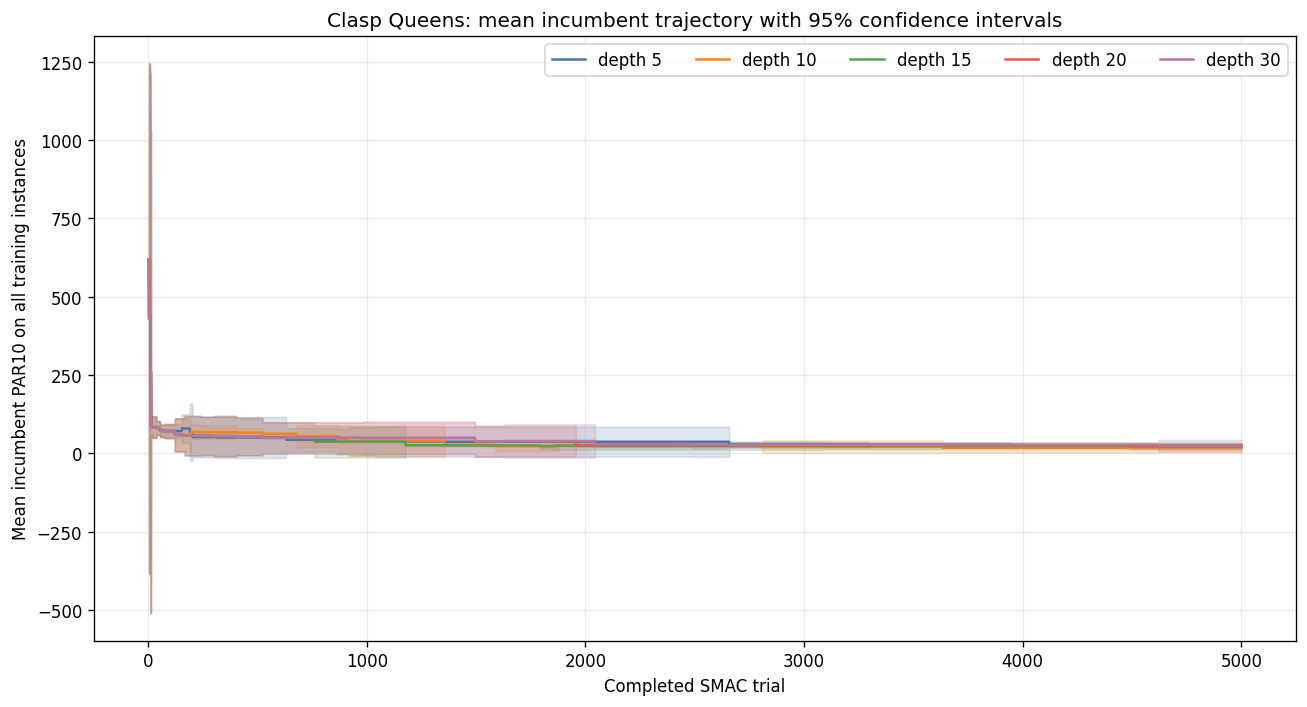

In [4]:
confidence_figure = plot_incumbent_confidence_intervals(bundle)
plt.show()

## 2b. Best incumbent depth within each 500-trial window

For every completed trial, the five independently validated incumbent values are compared and the depth with the lowest mean PAR10 receives one unit of credit. Exact numerical ties split that unit equally among the tied depths; consequently, every 500-trial window sums to exactly 500 without arbitrarily favoring one depth. The first three grouped-bar figures show individual SMAC seeds. The fourth figure is the arithmetic mean of the tie-adjusted counts across the three seeds. These are occupancy counts—not counts of incumbent changes.

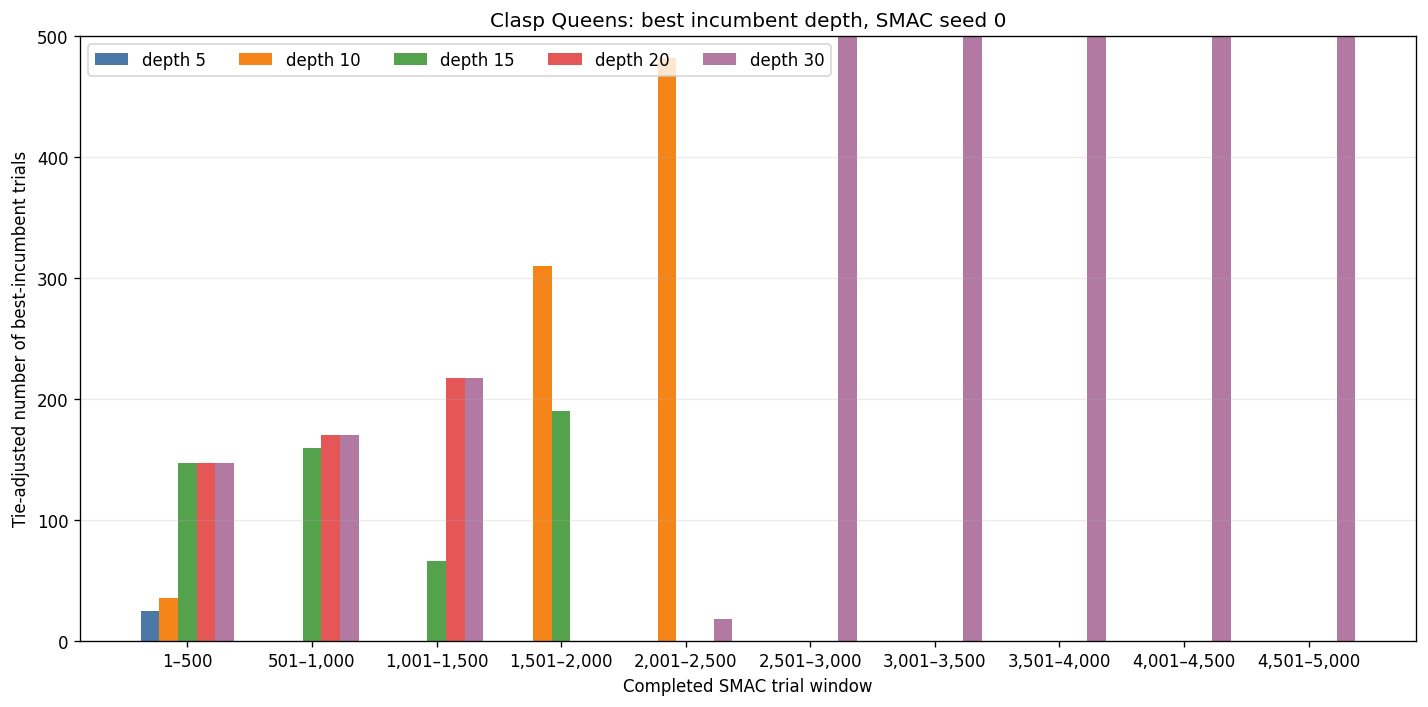

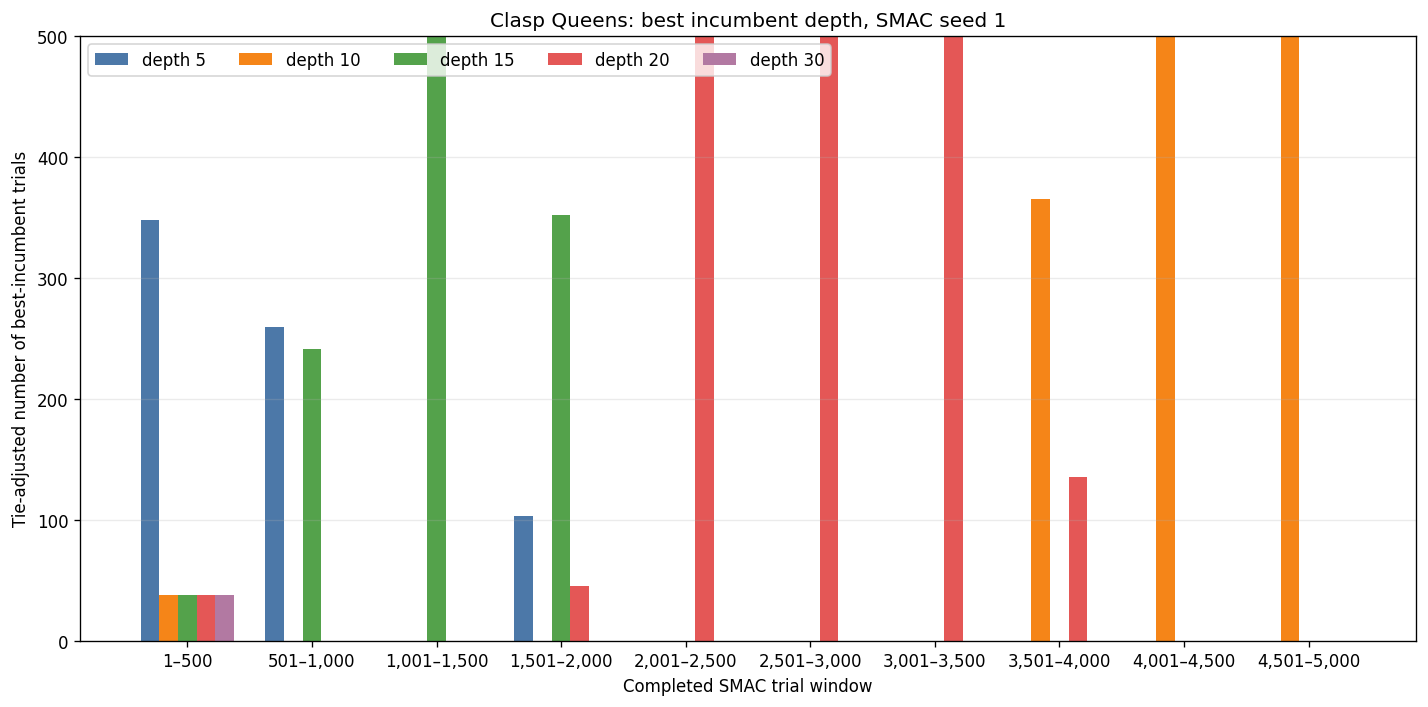

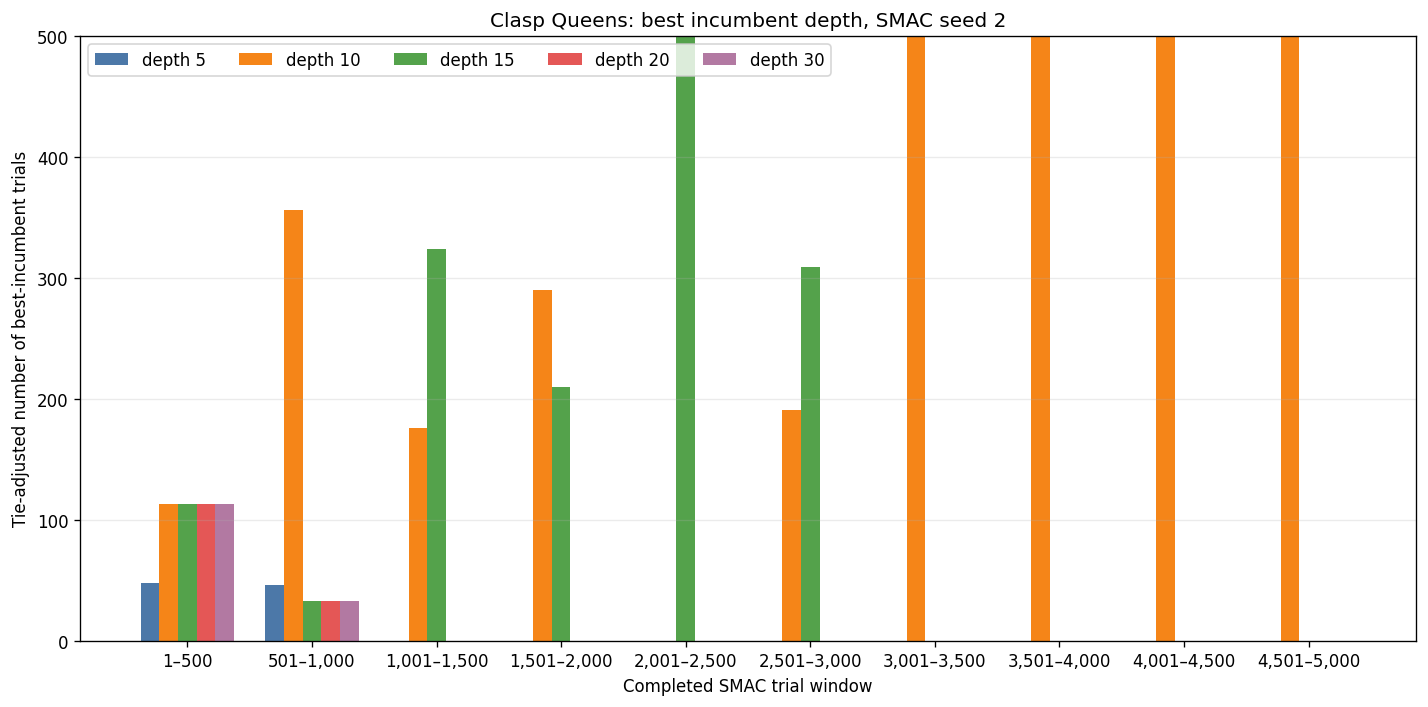

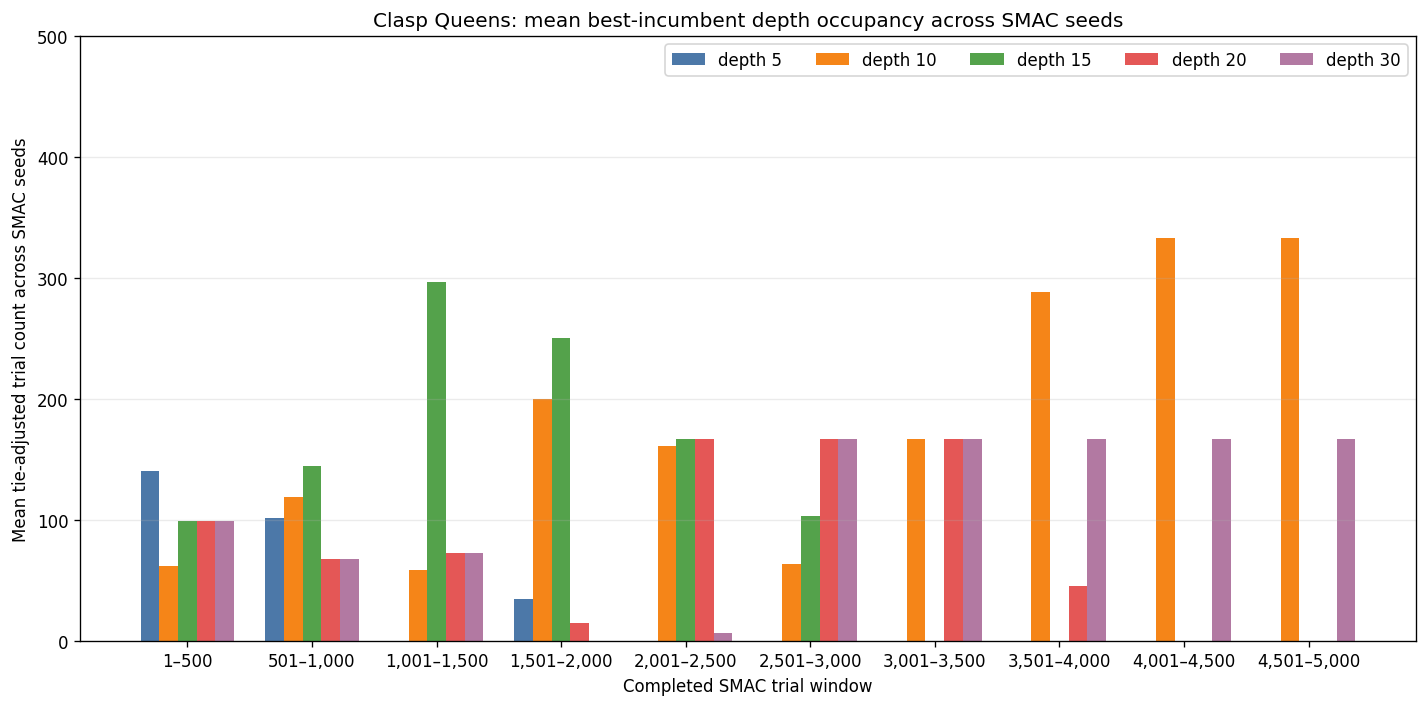

In [5]:
import numpy as np

WINDOW_SIZE = 500
WINDOW_STARTS = np.arange(0, N_TRIALS, WINDOW_SIZE)
WINDOW_LABELS = [
    f'{start + 1:,}–{start + WINDOW_SIZE:,}'
    for start in WINDOW_STARTS
]
DEPTH_COLORS = {
    5: '#4c78a8', 10: '#f58518', 15: '#54a24b',
    20: '#e45756', 30: '#b279a2',
}

def incumbent_values_for_seed(smac_seed):
    trial_grid = np.arange(1, N_TRIALS + 1)
    depth_values = []
    for depth in DEPTHS:
        events = bundle.trajectory_events[
            (bundle.trajectory_events['depth'] == depth)
            & (bundle.trajectory_events['smac_seed'] == smac_seed)
        ].sort_values('trial').drop_duplicates('trial', keep='last')
        event_trials = events['trial'].to_numpy(dtype=int)
        event_values = events['full_training_par10'].to_numpy(dtype=float)
        positions = np.searchsorted(event_trials, trial_grid, side='right') - 1
        if np.any(positions < 0):
            raise RuntimeError('An incumbent trajectory does not start at trial 1.')
        depth_values.append(event_values[positions])
    return np.vstack(depth_values)

def best_depth_counts_for_seed(smac_seed):
    values = incumbent_values_for_seed(smac_seed)
    best_values = np.min(values, axis=0, keepdims=True)
    tied_for_best = np.isclose(values, best_values, rtol=1e-10, atol=1e-12)
    trial_credit = tied_for_best / tied_for_best.sum(axis=0, keepdims=True)
    counts = np.vstack([
        trial_credit[:, start:start + WINDOW_SIZE].sum(axis=1)
        for start in WINDOW_STARTS
    ])
    if not np.allclose(counts.sum(axis=1), WINDOW_SIZE):
        raise RuntimeError('Tie-adjusted window counts do not sum to 500.')
    return counts

def plot_best_depth_counts(counts, title, ylabel):
    figure, axis = plt.subplots(figsize=(12, 6))
    group_positions = np.arange(len(WINDOW_STARTS))
    bar_width = 0.15
    for depth_index, depth in enumerate(DEPTHS):
        offsets = group_positions + (depth_index - 2) * bar_width
        axis.bar(
            offsets,
            counts[:, depth_index],
            width=bar_width,
            color=DEPTH_COLORS[depth],
            label=f'depth {depth}',
        )
    axis.set(
        xticks=group_positions,
        xticklabels=WINDOW_LABELS,
        xlabel='Completed SMAC trial window',
        ylabel=ylabel,
        title=title,
        ylim=(0, WINDOW_SIZE),
    )
    axis.grid(axis='y', alpha=0.25)
    axis.legend(ncol=len(DEPTHS))
    figure.tight_layout()
    return figure

best_depth_counts = {
    smac_seed: best_depth_counts_for_seed(smac_seed)
    for smac_seed in SMAC_SEEDS
}
for smac_seed in SMAC_SEEDS:
    plot_best_depth_counts(
        best_depth_counts[smac_seed],
        f'{bundle.display_name}: best incumbent depth, SMAC seed {smac_seed}',
        'Tie-adjusted number of best-incumbent trials',
    )
    plt.show()

mean_best_depth_counts = np.mean(
    np.stack(list(best_depth_counts.values())),
    axis=0,
)
plot_best_depth_counts(
    mean_best_depth_counts,
    f'{bundle.display_name}: mean best-incumbent depth occupancy across SMAC seeds',
    'Mean tie-adjusted trial count across SMAC seeds',
)
plt.show()

## 3. Final incumbent performance by RF depth

Scatter plot: the x-axis is the configured maximum RF depth and the y-axis is the final incumbent's mean PAR10 over every training instance. There are exactly three points per depth—one for each SMAC seed. Small horizontal offsets prevent overlapping points; they do not alter the depth.

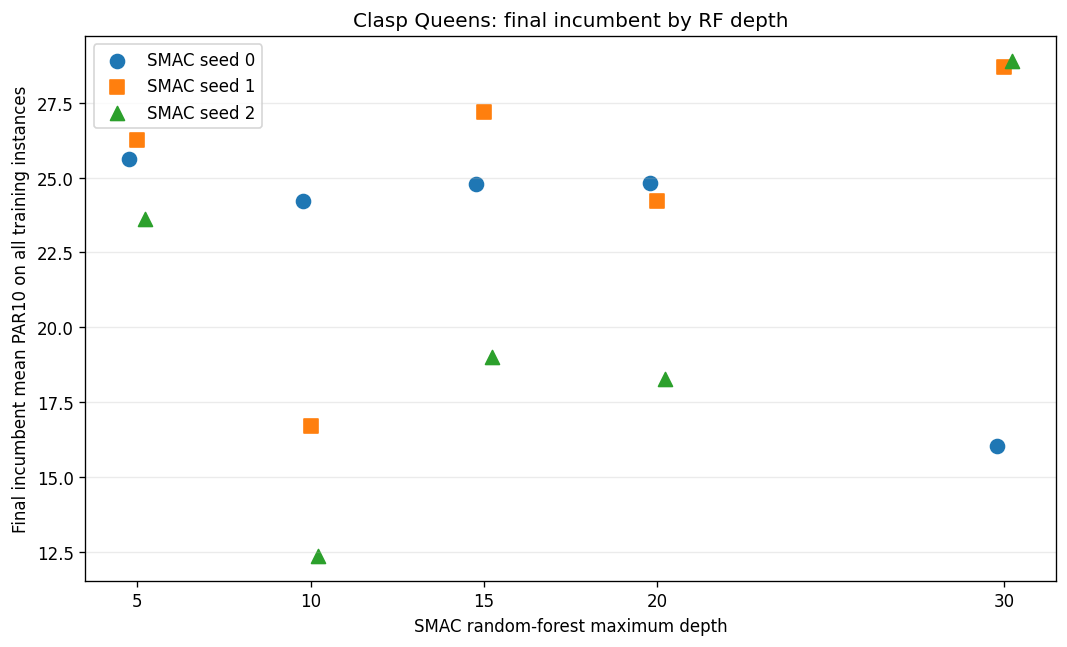

,depth,smac_seed,full_training_par10,config_id
0,5,0,25.601854,173
1,5,1,26.243285,545
2,5,2,23.623321,537
3,10,0,24.230729,300
4,10,1,16.701370,605
5,10,2,12.369495,402
6,15,0,24.790754,308
7,15,1,27.189507,480
8,15,2,19.010385,347
9,20,0,24.808152,828


In [6]:
final_figure = plot_final_incumbents(bundle)
plt.show()
display(
    bundle.final_incumbents[
        ['depth', 'smac_seed', 'full_training_par10', 'config_id']
    ].sort_values(['depth', 'smac_seed'])
)

## 4. Aligned model and optimization diagnostics for one SMAC seed

The eight panels below use SMAC seed 0 (change `SELECTED_SMAC_SEED` above to rebuild the cache and plots for seed 1 or 2) and show every RF depth as a separate line. Proposal metrics are placed at the trial where that configuration first completed an evaluation. The incumbent panel uses independently validated trajectory incumbents.

- **Predicted performance** is the SMAC RF mean marginalized over all training-instance feature vectors at proposal time.
- **Prediction variance** is the RF variance associated with that mean.
- **Absolute error** compares the prediction with a fresh evaluation of the proposal on all training instances at validation quantile seed 0.
- **Standardized error** is signed: `(validation − prediction) / predicted standard deviation`. Positive values mean the RF was optimistic for a minimization problem.
- **Average actual tree depth** is the arithmetic mean of `get_depth()` over all 100 fitted trees.

### What EI variance is and is not available

The telemetry contains the exact EI for every configuration that SMAC **selected and proposed for target evaluation**, plus a `fit_serial` identifying the RF fit that produced it. Therefore the last panel can calculate the population variance of EI across the up-to-eight selected proposals from each fit; its x-coordinate is the number of training rows used for that RF fit.

It cannot calculate EI variance over every configuration examined internally by the acquisition maximizer. SMAC considered 5,000 sorted-random challengers plus local-search neighbors, but discarded-candidate configurations and EI values were not persisted. The fitted RF objects were also not serialized, so those values cannot be reconstructed exactly after the run. Capturing that larger distribution in a future experiment would require instrumentation inside the acquisition maximizer and would produce substantially more telemetry.

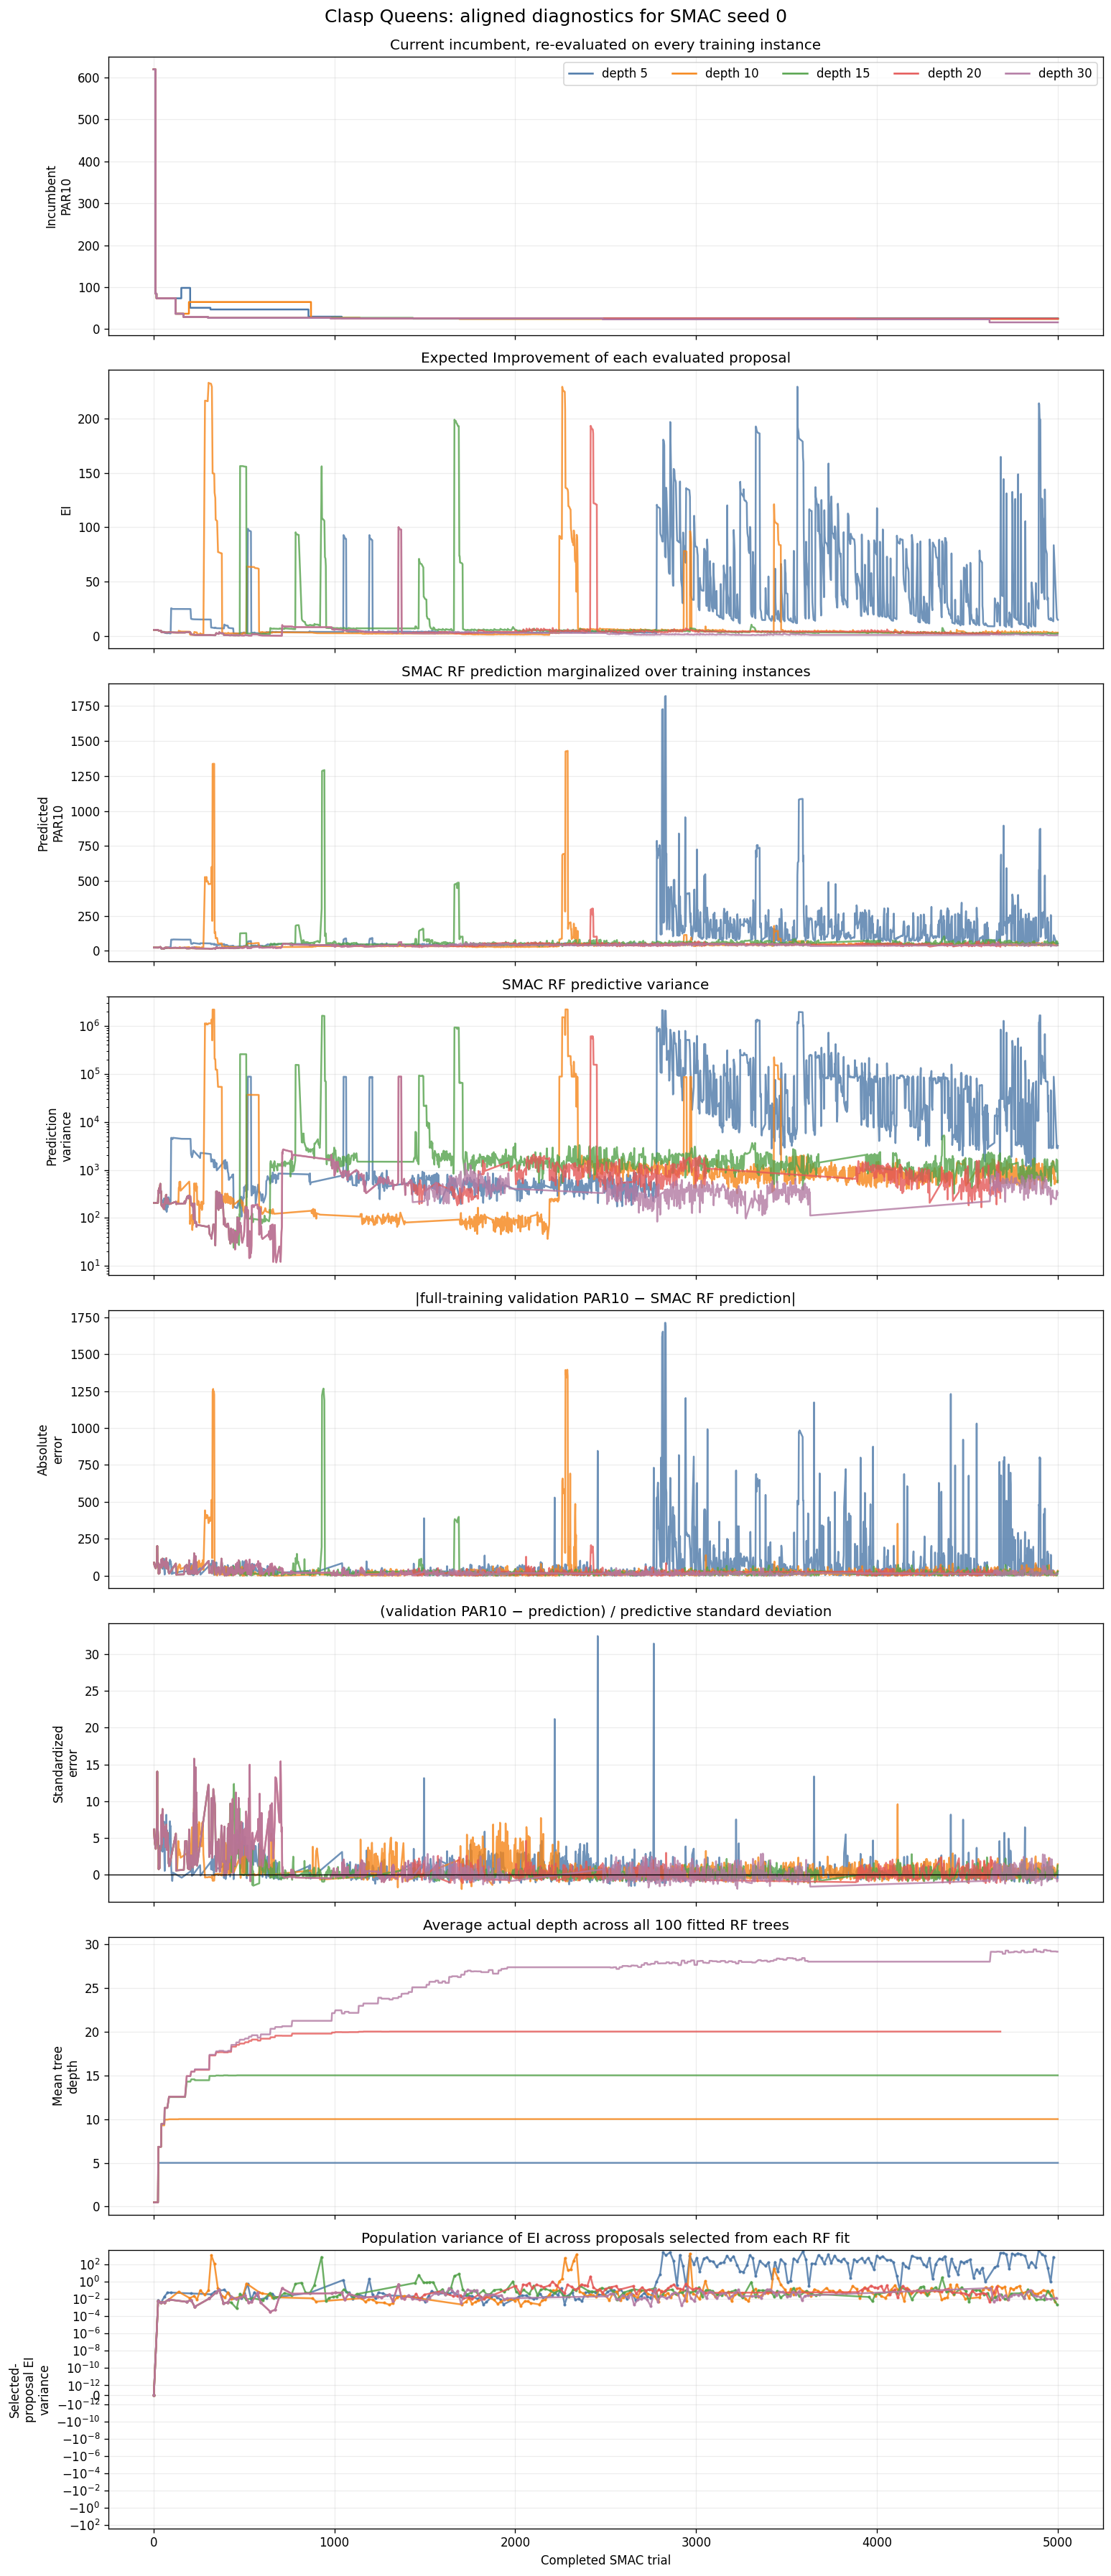

In [7]:
diagnostic_figure = plot_selected_seed_diagnostics(
    bundle,
    selected_seed=SELECTED_SMAC_SEED,
)
plt.show()

## Diagnostic coverage table

Table: number of trained proposals and RF retraining checkpoints represented in each depth's selected-seed diagnostic. `mean_selected_per_fit` is the average number of configurations retained for evaluation from each RF fit; it is not the number of discarded random/local-search candidates.

In [8]:
coverage = (
    bundle.proposal_diagnostics.groupby('depth')
    .agg(
        trained_proposals=('configuration_fingerprint', 'size'),
        rf_fits=('fit_serial', 'nunique'),
        mean_absolute_error=('absolute_error', 'mean'),
        mean_standardized_error=('standardized_error', 'mean'),
    )
)
selected_counts = (
    bundle.ei_batch_variance.groupby('depth')['selected_proposal_count']
    .mean()
    .rename('mean_selected_per_fit')
)
display(coverage.join(selected_counts))

,trained_proposals,rf_fits,mean_absolute_error,mean_standardized_error,mean_selected_per_fit
depth,,,,,
5,1741,218,83.632656,0.534654,7.986239
10,1700,213,38.354435,0.658485,7.981221
15,1386,174,27.452650,0.437587,7.965517
20,1122,141,22.972973,0.940822,7.957447
30,1156,145,20.822786,0.826141,7.972414
